# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [652]:
ПІБ = 'Паничевська Ярина Ернестівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 15    # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [653]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Паничевська Ярина Ернестівна, ШІ-32, варіант 15
ваш потік:                   E>0.8
ваша пара для графіка 3:     потік E>0.8 та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [654]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [655]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)
display(df.head(5))
print("------------------------------------------------------------------------------------------------------------------------")
print(df.info())

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7225 entries, 0 to 7224
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   0 non-null      float64
 1   ftp://ftp.swpc.noaa.gov/pub/lists/particle/  7222 non-null   object 
 2   Unnamed: 2                                   7202 non-null   object 
 3   Unnamed: 3                                   7202 non-null   object 
 4   Unnamed: 4                                   7202 non-null   object 
 5   Unnamed: 5                                   7203 non-null   object 
 6   Unnamed: 6                                   7203 non-null   object 
 7   Unnamed: 7                                   7198 non-null   object 
 8   Unnamed: 8                 

**Відповідь 1.1:** *Звичайне читання дало такий результат, оскільки, цей файл не має в собі відформатованої таблиці і його перші рядки містять метадані, описи та посилання, які pandas інтерпретує як заголовки до колонок. 
Unnamed - автоматично згенеровані назви колонок на випадок, якщо не має ім'я.
Nan - позначення порожніх клітинок в самих даних.*

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [656]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
display(RAW.head(30))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [657]:
# ВАШ КОД
print(RAW.notna().sum())


0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *Всього 3 таблиці.
Перша охоплює з 2-ї по 15-ту колонку (B-O), друга - з 17-ї по 20-ту (Q-U), третя - з 25-ї по 32-гу (Y-AF) (переведено на індексацію з 1).*

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [658]:
print('TABLE 1')
print(RAW.iloc[0:30, 1].dropna().values)

TABLE 1
['ftp://ftp.swpc.noaa.gov/pub/lists/particle/'
 ':Data_list: 20170901_Gs_part_5m.txt' ':Created: 2017 Sep 02 0011 UTC'
 '# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center'
 '# Please send comments and suggestions to SWPC.Webmaster@noaa.gov ' '# '
 '# Label: P > 1 = Particles at >1 Mev'
 '# Label: P > 5 = Particles at >5 Mev'
 '# Label: P >10 = Particles at >10 Mev'
 '# Label: P >30 = Particles at >30 Mev'
 '# Label: P >50 = Particles at >50 Mev'
 '# Label: P>100 = Particles at >100 Mev'
 '# Label: E>0.8 = Electrons at >0.8 Mev'
 '# Label: E>2.0 = Electrons at >2.0 Mev'
 '# Label: E>4.0 = Electrons at >4.0 Mev'
 '# Units: Particles = Protons/cm2-s-sr'
 '# Units: Electrons = Electrons/cm2-s-sr' '# Source: GOES-15'
 '# Location: W135' '# Missing data: -1.00e+05'
 '5-minute  GOES-15 Solar Particle and Electron Flux' '# UT' '# YR' 2017
 2017 2017 2017]


In [659]:
print('TABLE 2')
print(RAW.iloc[0:30, 16:21].dropna(how='all').values)

TABLE 2
[['ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt' nan
  nan nan nan]
 ['Product: Daily Solar Data         quar_DSD.txt' nan nan nan nan]
 [':Issued: 0825 UT 04 Oct 2017' nan nan nan nan]
 ['#' nan nan nan nan]
 ['#  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center'
  nan nan nan nan]
 ['#  Please send comments and suggestions to SWPC.Webmaster@noaa.gov'
  nan nan nan nan]
 ['Quarterly Daily Solar Data' nan nan nan nan]
 [nan 'Month' 'Date' 'Radio Flux 10.7' nan]
 [2017 8 28 82 nan]
 [2017 8 29 84 nan]
 [2017 8 30 87 nan]]


In [660]:
print('TABLE 3')
print(RAW.iloc[0:30, 26].dropna().values)

TABLE 3
['http://umtof.umd.edu/pm/crn/' 'SOHO CELIAS Proton Monitor'
 'Solar Wind Parameters for Carrington Rotation (hour averages)'
 'Proton speed [km/sec]' 'Proton density [protons per cubic centimeter]'
 'Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second)'
 '# YR' 17 17 17]


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15, U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center (ftp://ftp.swpc.noaa.gov/pub/lists/particle/) | Protons/cm2-s-sr, Electrons/cm2-s-sr |
| B | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center (ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt) | solar flux units (sfu) |
| C | SOHO CELIAS Proton Monitor (http://umtof.umd.edu/pm/crn/) | km/sec, protons per cubic centimeter |


*Примітка:* *у другій таблиці в службовому описі не було прямо вказано одиниці вимірювання, тому довелося взяти частину колонок даних, щоб побачити.*

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [661]:
# ВАШ КОД
A = RAW.iloc[26:7226, 1:15].copy()
B = RAW.iloc[27:52,16:20].copy()
C = RAW.iloc[27:628, 26:32].copy()

In [662]:
A.reset_index(drop=True, inplace=True)
B.reset_index(drop=True, inplace=True)
C.reset_index(drop=True, inplace=True)

In [663]:
A = A.apply(pd.to_numeric, errors='coerce')
B = B.apply(pd.to_numeric, errors='coerce')
С = C.apply(pd.to_numeric, errors='coerce')

In [664]:
A.columns = ['year', 'month', 'day', 'hhmm', 'julian_day', 'seconds_of_day', 
        'p_grt_1', 'p_grt_5', 'p_grt_10', 'p_grt_30', 'p_grt_50', 'p_grt_100', 
        'e_grt_08', 'e_grt_02']
B.columns = ['year', 'month', 'day', 'sfu']
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [665]:
A['hour'], A['minutes'] = A['hhmm'] // 100, A['hhmm'] % 100

In [666]:
A['ts'] = pd.to_datetime(A[['year', 'month', 'day', 'hour', 'minutes']])

In [667]:
B['ts'] = pd.to_datetime(B[['year', 'month', 'day']])

In [668]:
C['year'], C['month'], C['day'], C['speed'], C['density'], C['hour'] = C['year'].astype(int), C['month'].astype(int), C['day'].astype(int), C['speed'].astype(int), C['density'].astype(int), C['hour'].astype(int)

In [669]:
C['year'] = C['year'] + 2000

In [670]:
C['ts'] = pd.to_datetime(C[['year', 'month', 'day', 'hour']])

In [671]:
display(A['ts'])

0      2017-08-28 00:00:00
1      2017-08-28 00:05:00
2      2017-08-28 00:10:00
3      2017-08-28 00:15:00
4      2017-08-28 00:20:00
               ...        
7195   2017-09-21 23:35:00
7196   2017-09-21 23:40:00
7197   2017-09-21 23:45:00
7198   2017-09-21 23:50:00
7199   2017-09-21 23:55:00
Name: ts, Length: 7200, dtype: datetime64[ns]

In [672]:
display(B['ts'])

0    2017-08-28
1    2017-08-29
2    2017-08-30
3    2017-08-31
4    2017-09-01
5    2017-09-02
6    2017-09-03
7    2017-09-04
8    2017-09-05
9    2017-09-06
10   2017-09-07
11   2017-09-08
12   2017-09-09
13   2017-09-10
14   2017-09-11
15   2017-09-12
16   2017-09-13
17   2017-09-14
18   2017-09-15
19   2017-09-16
20   2017-09-17
21   2017-09-18
22   2017-09-19
23   2017-09-20
24   2017-09-21
Name: ts, dtype: datetime64[ns]

In [673]:
display(C['ts'])

0     2017-08-28 00:00:00
1     2017-08-28 01:00:00
2     2017-08-28 02:00:00
3     2017-08-28 03:00:00
4     2017-08-28 04:00:00
              ...        
596   2017-09-21 20:00:00
597   2017-09-21 21:00:00
598   2017-09-21 22:00:00
599   2017-09-21 23:00:00
600   2017-09-22 00:00:00
Name: ts, Length: 601, dtype: datetime64[ns]

**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [674]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [675]:
print('TABLE A')
print(f"\nКількість рядків: {len(A)}")
print(f"\nКількість стовпців: {len(A.columns)}")
print(f"\nТипи стовпців: \n{A.dtypes}")
print(f"\nКількість пропусків у кожному стовпці: \n{A.isna().sum()}")
print(f"\nКількість повних дублікатів: {A.duplicated(keep='first').sum()}")
print(f"\nОписові статистики:\n{A.describe()}")

TABLE A

Кількість рядків: 7200

Кількість стовпців: 17

Типи стовпців: 
year                       int64
month                      int64
day                        int64
hhmm                       int64
julian_day                 int64
seconds_of_day             int64
p_grt_1                  float64
p_grt_5                  float64
p_grt_10                 float64
p_grt_30                 float64
p_grt_50                 float64
p_grt_100                float64
e_grt_08                 float64
e_grt_02                 float64
hour                       int64
minutes                    int64
ts                datetime64[ns]
dtype: object

Кількість пропусків у кожному стовпці: 
year              0
month             0
day               0
hhmm              0
julian_day        0
seconds_of_day    0
p_grt_1           3
p_grt_5           3
p_grt_10          3
p_grt_30          3
p_grt_50          3
p_grt_100         3
e_grt_08          3
e_grt_02          3
hour              0
minutes    

In [676]:
print('TABLE B')
print(f"\nКількість рядків: {len(B)}")
print(f"\nКількість стовпців: {len(B.columns)}")
print(f"\nТипи стовпців: \n{B.dtypes}")
print(f"\nКількість пропусків у кожному стовпці: \n{B.isna().sum()}")
print(f"\nКількість повних дублікатів: {B.duplicated(keep='first').sum()}")
print(f"\nОписові статистики:\n{B.describe()}")

TABLE B

Кількість рядків: 25

Кількість стовпців: 5

Типи стовпців: 
year              int64
month             int64
day               int64
sfu               int64
ts       datetime64[ns]
dtype: object

Кількість пропусків у кожному стовпці: 
year     0
month    0
day      0
sfu      0
ts       0
dtype: int64

Кількість повних дублікатів: 0

Описові статистики:
         year      month        day         sfu                   ts
count    25.0  25.000000  25.000000   25.000000                   25
mean   2017.0   8.840000  13.960000   92.680000  2017-09-09 00:00:00
min    2017.0   8.000000   1.000000   71.000000  2017-08-28 00:00:00
25%    2017.0   9.000000   7.000000   74.000000  2017-09-03 00:00:00
50%    2017.0   9.000000  13.000000   84.000000  2017-09-09 00:00:00
75%    2017.0   9.000000  19.000000  107.000000  2017-09-15 00:00:00
max    2017.0   9.000000  31.000000  140.000000  2017-09-21 00:00:00
std       0.0   0.374166   8.955817   22.206831                  NaN


In [677]:
print('TABLE C')
print(f"\nКількість рядків: {len(C)}")
print(f"\nКількість стовпців: {len(C.columns)}")
print(f"\nТипи стовпців: \n{C.dtypes}")
print(f"\nКількість пропусків у кожному стовпці: \n{C.isna().sum()}")
print(f"\nКількість повних дублікатів: {C.duplicated(keep='first').sum()}")
print(f"\nОписові статистики:\n{C.describe()}")

TABLE C

Кількість рядків: 601

Кількість стовпців: 7

Типи стовпців: 
year                int64
month               int64
day                 int64
hour                int64
speed               int64
density             int64
ts         datetime64[ns]
dtype: object

Кількість пропусків у кожному стовпці: 
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0
dtype: int64

Кількість повних дублікатів: 0

Описові статистики:
         year       month         day        hour       speed     density                   ts
count   601.0  601.000000  601.000000  601.000000  601.000000  601.000000                  601
mean   2017.0    8.840266   13.973378   11.480865  506.547421    2.469218  2017-09-09 12:00:00
min    2017.0    8.000000    1.000000    0.000000   -1.000000   -1.000000  2017-08-28 00:00:00
25%    2017.0    9.000000    7.000000    5.000000  447.000000    1.000000  2017-09-03 06:00:00
50%    2017.0    9.000000   13.000000   11.000000  517.00000

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [678]:
print(f"Кількість від'ємних значень у колонці швидкість та густина: {(C['speed'] < 0).sum()}, {(C['density'] < 0).sum()}")

Кількість від'ємних значень у колонці швидкість та густина: 8, 8


In [679]:
print(f"Середній показник у колонці швидкість та густина: {C['speed'].mean()}, {(C['density'] < 0).mean()}")
print(f"Мінімальний показник у колонці швидкість та густина: {C['speed'].min()}, {C['density'].min()}")

Середній показник у колонці швидкість та густина: 506.5474209650582, 0.013311148086522463
Мінімальний показник у колонці швидкість та густина: -1, -1


In [680]:
C['speed'] = C['speed'].mask(C['speed'] < 0, np.nan)
C['density'] = C['density'].mask(C['density'] < 0, np.nan)

In [681]:
print(f"Кількість від'ємних значень у колонці швидкість та густина: {(C['speed'] < 0).sum()}, {(C['density'] < 0).sum()}")

Кількість від'ємних значень у колонці швидкість та густина: 0, 0


In [682]:
print(f"Середній показник у колонці швидкість та густина: {C['speed'].mean()}, {(C['density'] < 0).mean()}")
print(f"Мінімальний показник у колонці швидкість та густина: {C['speed'].min()}, {C['density'].min()}")

Середній показник у колонці швидкість та густина: 513.3946037099494, 0.0
Мінімальний показник у колонці швидкість та густина: 277.0, 0.0


**Відповідь 3.2:** У таблиці знайдено по 8 записів "-1" у кожному зі стовпців speed та density. Такі значення називають sentinel value (контрольне значення або фіктивне значення) і їх використовують як спеціальний маркер того, що дані відсутні, коли система вимагає обов'язкове ведення числа. Раніше практикували ставити -1 і перед проведенням аналізу викидали рядки де зустрічалось це значення, але за теперішньою нормою ставлять Nan або None, бо це чітко вказує системі, що даних нема і вони не будуть спотворювати арифметичні показники.

Після зміни -1 на NaN середня швидкість зросла з 506.55 до 513.39 км/с, а середня густина змінилась з 0.01 на 0.0 протонів/см^3. 
Мінімум до заміни показував -1, а після - реальні фізичні значення (277 км/с і 0.0 протонів/см^3 відповідно).


### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [683]:
print(A.describe())

         year        month          day         hhmm    julian_day  seconds_of_day       p_grt_1      p_grt_5     p_grt_10     p_grt_30     p_grt_50   p_grt_100       e_grt_08       e_grt_02  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000     7200.000000   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000    7197.000000   
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000    43050.000000    689.325064   156.626057    76.474020    18.838604     7.446840     1.65929   81862.741801   11401.502123   
min    2017.0     8.000000     1.000000     0.000000  57993.000000        0.000000      0.429000     0.151000     0.117000     0.057600     0.045500     0.02240       4.300000       0.133000   
25%    2017.0     9.000000     7.000000   588.750000  57999.000000    21525.000000     11.700000     0.279000     0.186000     0.098400     0.059700     0.02630   22200.000000     552.000000   
50%    2017.0     9.000000    

**Відповідь 3.3:**
Стовпці year, month, day, hhmm, julian_day, seconds_of_day - це все часові мітки і їхнє середнє й стандартне відхилення не мають фізичного змісту. До прикладу, формулювання "середній день місяця" чи "середній hhmm" не несе жодної відомості про дослідження.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [684]:
streams = ['p_grt_1',	'p_grt_5',	'p_grt_10',	'p_grt_30',	'p_grt_50',	'p_grt_100', 'e_grt_08','e_grt_02']
idx = A.set_index('ts')

In [685]:
idx.head(5)

,year,month,day,hhmm,julian_day,seconds_of_day,p_grt_1,p_grt_5,p_grt_10,p_grt_30,p_grt_50,p_grt_100,e_grt_08,e_grt_02,hour,minutes
ts,,,,,,,,,,,,,,,,
2017-08-28 00:00:00,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0,0,0
2017-08-28 00:05:00,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0,0,5
2017-08-28 00:10:00,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0,0,10
2017-08-28 00:15:00,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0,0,15
2017-08-28 00:20:00,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0,0,20


In [686]:
A_hourly = idx[streams].resample('h').agg(['mean', 'max'])

In [687]:
A_hourly.head(5)

p_grt_1          p_grt_5         p_grt_10         p_grt_30          p_grt_50         p_grt_100              e_grt_08              e_grt_02        
                         mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
ts                                                                                                                                                                      
2017-08-28 00:00:00  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
2017-08-28 01:00:00  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2017-08-28 02:00:00  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
2017-08-28 03:00:00  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
2017-08-28 04:00:00  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

In [688]:
A_hourly.columns = [f'{col}_{stat}' for col, stat in A_hourly.columns]

In [689]:
A_hourly = A_hourly.reset_index()

In [690]:
A_hourly.head(5)

,ts,p_grt_1_mean,p_grt_1_max,p_grt_5_mean,p_grt_5_max,p_grt_10_mean,p_grt_10_max,p_grt_30_mean,p_grt_30_max,p_grt_50_mean,p_grt_50_max,p_grt_100_mean,p_grt_100_max,e_grt_08_mean,e_grt_08_max,e_grt_02_mean,e_grt_02_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

In [691]:
day = A[(A['ts'] >= '2017-08-28') & (A['ts'] < '2017-08-29')]

In [692]:
day = day.set_index('ts')

In [693]:
mean_hour = day['e_grt_08'].resample('h').mean()
mean_hour

ts
2017-08-28 00:00:00    20941.666667
2017-08-28 01:00:00    18091.666667
2017-08-28 02:00:00    14108.333333
2017-08-28 03:00:00    12766.666667
2017-08-28 04:00:00    11333.333333
2017-08-28 05:00:00     9685.833333
2017-08-28 06:00:00     8650.000000
2017-08-28 07:00:00     6424.166667
2017-08-28 08:00:00     4602.500000
2017-08-28 09:00:00     4761.666667
2017-08-28 10:00:00     4598.333333
2017-08-28 11:00:00     5865.833333
2017-08-28 12:00:00     9123.333333
2017-08-28 13:00:00    12200.000000
2017-08-28 14:00:00    13875.000000
2017-08-28 15:00:00    15925.000000
2017-08-28 16:00:00    18016.666667
2017-08-28 17:00:00    20050.000000
2017-08-28 18:00:00    20883.333333
2017-08-28 19:00:00    22058.333333
2017-08-28 20:00:00    23108.333333
2017-08-28 21:00:00    24550.000000
2017-08-28 22:00:00    25641.666667
2017-08-28 23:00:00    24866.666667
Freq: h, Name: e_grt_08, dtype: float64

In [694]:
min_hour = day['e_grt_08'].resample('h').min()
min_hour

ts
2017-08-28 00:00:00    18500.0
2017-08-28 01:00:00    14800.0
2017-08-28 02:00:00    13000.0
2017-08-28 03:00:00    12300.0
2017-08-28 04:00:00    10800.0
2017-08-28 05:00:00     9080.0
2017-08-28 06:00:00     7610.0
2017-08-28 07:00:00     5360.0
2017-08-28 08:00:00     4120.0
2017-08-28 09:00:00     4460.0
2017-08-28 10:00:00     4250.0
2017-08-28 11:00:00     4950.0
2017-08-28 12:00:00     7490.0
2017-08-28 13:00:00    11000.0
2017-08-28 14:00:00    13000.0
2017-08-28 15:00:00    14400.0
2017-08-28 16:00:00    17000.0
2017-08-28 17:00:00    18800.0
2017-08-28 18:00:00    20300.0
2017-08-28 19:00:00    22000.0
2017-08-28 20:00:00    22000.0
2017-08-28 21:00:00    23800.0
2017-08-28 22:00:00    24600.0
2017-08-28 23:00:00    23900.0
Freq: h, Name: e_grt_08, dtype: float64

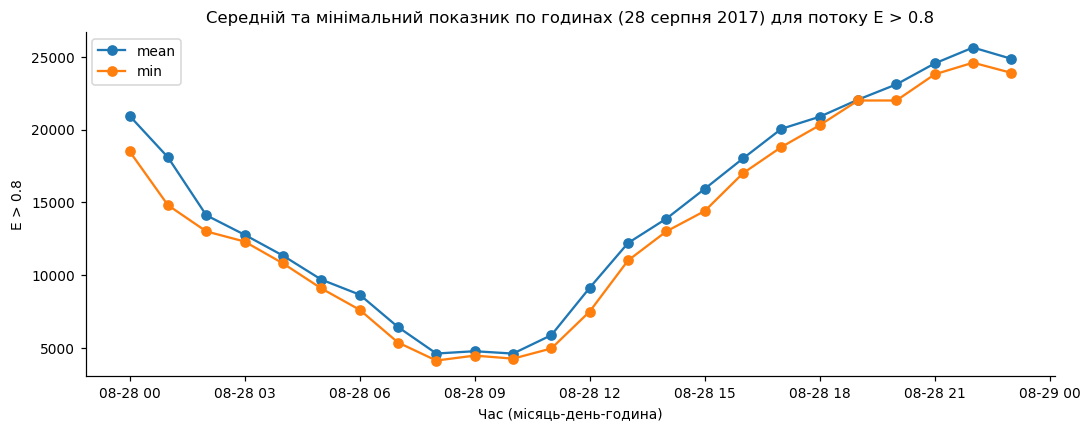

In [695]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_hour.index, mean_hour.values, label='mean', marker='o')
ax.plot(min_hour.index,  min_hour.values,  label='min',  marker='o')
ax.set_xlabel('Час (місяць-день-година)')
ax.set_ylabel('E > 0.8')
ax.set_title('Cередній та мінімальний показник по годинах (28 серпня 2017) для потоку E > 0.8')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *На графіку видно, що криві середньої (mean) та мінімальної (min) не сильно розходяться, тому що значення потоку змінювалось плавно по годинах в межах цієї доби без різких провалів.
Різниця була б суттєвої, якби всередині якоїсь години був короткий різкий спад - тоді min "провалився" б через цей один викид, а mean залишився б майже без змін, бо усереднює всі виміри за годину.*

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [696]:
B_hourly = B.set_index('ts').resample('h').ffill().reset_index()

In [697]:
C_clean = C[['ts', 'speed', 'density']]
B_clean = B_hourly[['ts', 'sfu']]

In [698]:
M_inner = pd.merge(A_hourly, C_clean, on='ts', how='inner')
M_inner = pd.merge(M_inner, B_clean, on='ts', how='inner')
display(M_inner)
print(M_inner[M_inner.isna().any(axis=1)])

,ts,p_grt_1_mean,p_grt_1_max,p_grt_5_mean,p_grt_5_max,p_grt_10_mean,p_grt_10_max,p_grt_30_mean,p_grt_30_max,p_grt_50_mean,p_grt_50_max,p_grt_100_mean,p_grt_100_max,e_grt_08_mean,e_grt_08_max,e_grt_02_mean,e_grt_02_max,speed,density,sfu
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0,285.0,3.0,82
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0,305.0,3.0,82
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0,309.0,1.0,82
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0,304.0,2.0,82
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0,302.0,2.0,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,2017-09-20 20:00:00,91.175000,131.00,0.285500,0.455,0.200583,0.294,0.090975,0.1360,0.060417,0.0959,0.029025,0.0483,212333.333333,218000.0,85025.000000,96600.0,449.0,3.0,74
573,2017-09-20 21:00:00,84.366667,118.00,0.266833,0.493,0.193000,0.328,0.094325,0.1240,0.065642,0.1000,0.031525,0.0514,200250.000000,208000.0,72833.333333,78800.0,455.0,3.0,74
574,2017-09-20 22:00:00,71.708333,114.00,0.259583,0.386,0.208917,0.346,0.098908,0.1680,0.069875,0.1390,0.035517,0.0613,190333.333333,197000.0,61433.333333,66800.0,453.0,2.0,74
575,2017-09-20 23:00:00,59.583333,91.50,0.244083,0.373,0.184667,0.333,0.096833,0.1590,0.064800,0.1040,0.035075,0.0662,178333.333333,184000.0,51841.666667,54800.0,455.0,2.0,74


                     ts  p_grt_1_mean  p_grt_1_max  p_grt_5_mean  p_grt_5_max  p_grt_10_mean  p_grt_10_max  p_grt_30_mean  p_grt_30_max  p_grt_50_mean  p_grt_50_max  p_grt_100_mean  p_grt_100_max  \
175 2017-09-04 07:00:00      6.465833        10.10      0.262083        0.593       0.171500         0.294       0.085483         0.145       0.068558         0.134        0.031717         0.0523   
176 2017-09-04 08:00:00      4.010833         5.08      0.256000        0.432       0.195833         0.336       0.086625         0.145       0.070033         0.134        0.036492         0.0546   
177 2017-09-04 09:00:00      3.268333         4.42      0.303417        0.518       0.220333         0.302       0.105925         0.162       0.081975         0.134        0.046483         0.0765   
178 2017-09-04 10:00:00      3.179167         4.74      0.252167        0.372       0.181833         0.280       0.101900         0.150       0.081675         0.120        0.054125         0.0894   
179 2

In [699]:
M_outer = pd.merge(A_hourly, C_clean, on='ts', how='outer')
M_outer = pd.merge(M_outer, B_clean, on='ts', how='outer')
display(M_outer)
print(M_outer[M_outer.isna().any(axis=1)])

,ts,p_grt_1_mean,p_grt_1_max,p_grt_5_mean,p_grt_5_max,p_grt_10_mean,p_grt_10_max,p_grt_30_mean,p_grt_30_max,p_grt_50_mean,p_grt_50_max,p_grt_100_mean,p_grt_100_max,e_grt_08_mean,e_grt_08_max,e_grt_02_mean,e_grt_02_max,speed,density,sfu
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0,285.0,3.0,82.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0,305.0,3.0,82.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0,309.0,1.0,82.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0,304.0,2.0,82.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0,302.0,2.0,82.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,2017-09-21 20:00:00,42.102500,78.90,0.397500,0.833,0.226833,0.429,0.089325,0.1380,0.069983,0.1050,0.039692,0.0737,178750.000000,186000.0,63175.000000,70500.0,379.0,1.0,NaN
597,2017-09-21 21:00:00,50.783333,71.70,0.489250,0.788,0.317583,0.501,0.121358,0.2040,0.077467,0.1470,0.033417,0.0524,175833.333333,177000.0,58350.000000,60300.0,380.0,1.0,NaN
598,2017-09-21 22:00:00,39.000000,48.80,0.350000,0.536,0.200250,0.310,0.094358,0.1430,0.070633,0.1080,0.039600,0.0798,167750.000000,176000.0,49366.666667,54400.0,387.0,1.0,NaN
599,2017-09-21 23:00:00,28.825000,42.10,0.465000,0.861,0.257833,0.506,0.113575,0.1680,0.078108,0.1110,0.045125,0.0733,150083.333333,160000.0,37525.000000,44400.0,380.0,1.0,NaN


                     ts  p_grt_1_mean  p_grt_1_max  p_grt_5_mean  p_grt_5_max  p_grt_10_mean  p_grt_10_max  p_grt_30_mean  p_grt_30_max  p_grt_50_mean  p_grt_50_max  p_grt_100_mean  p_grt_100_max  \
175 2017-09-04 07:00:00      6.465833        10.10      0.262083        0.593       0.171500         0.294       0.085483         0.145       0.068558        0.1340        0.031717         0.0523   
176 2017-09-04 08:00:00      4.010833         5.08      0.256000        0.432       0.195833         0.336       0.086625         0.145       0.070033        0.1340        0.036492         0.0546   
177 2017-09-04 09:00:00      3.268333         4.42      0.303417        0.518       0.220333         0.302       0.105925         0.162       0.081975        0.1340        0.046483         0.0765   
178 2017-09-04 10:00:00      3.179167         4.74      0.252167        0.372       0.181833         0.280       0.101900         0.150       0.081675        0.1200        0.054125         0.0894   
179 2

In [700]:
M = M_outer

**Відповідь 4.3:** 
inner join виконує перетин таблиць, залишаючи лише ті рядки, які присутні одночасно в усіх таблицях. Розмір цієї таблиці вийшов  577x20

outer join об'єднує всі таблиці повністю, залишаючи унікальні рядки. Якщо ключ є лише в одній таблиці, для відсутніх полів з іншої таблиці проставляється значення NaN. Розмір таблиці вийшов 601x20

Я обираю outer join, оскільки це дозволяє зберегти повні дані з усіх досліджень. Навіть якщо в певних часових проміжках для якогось показника стоятиме NaN, я не втрачу наявну та потенційно корисну інформацію з інших таблиць за цей же час.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [701]:
M['група'] = pd.cut(x=M['p_grt_10_max'], bins=[-np.inf, 10, 1000, np.inf], right=False, labels=['тиха','активна','дуже активна'])

**Самоперевірка етапу 4.**

In [702]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

In [703]:
stream = M['e_grt_08_mean']
mean = stream.mean()
median = stream.median()
print(f'Середнє значення потоку E > 0.8: {mean}')
print(f'Медіанне значення потоку E > 0.8: {median}')

Середнє значення потоку E > 0.8: 81842.46818358586
Медіанне значення потоку E > 0.8: 69712.5


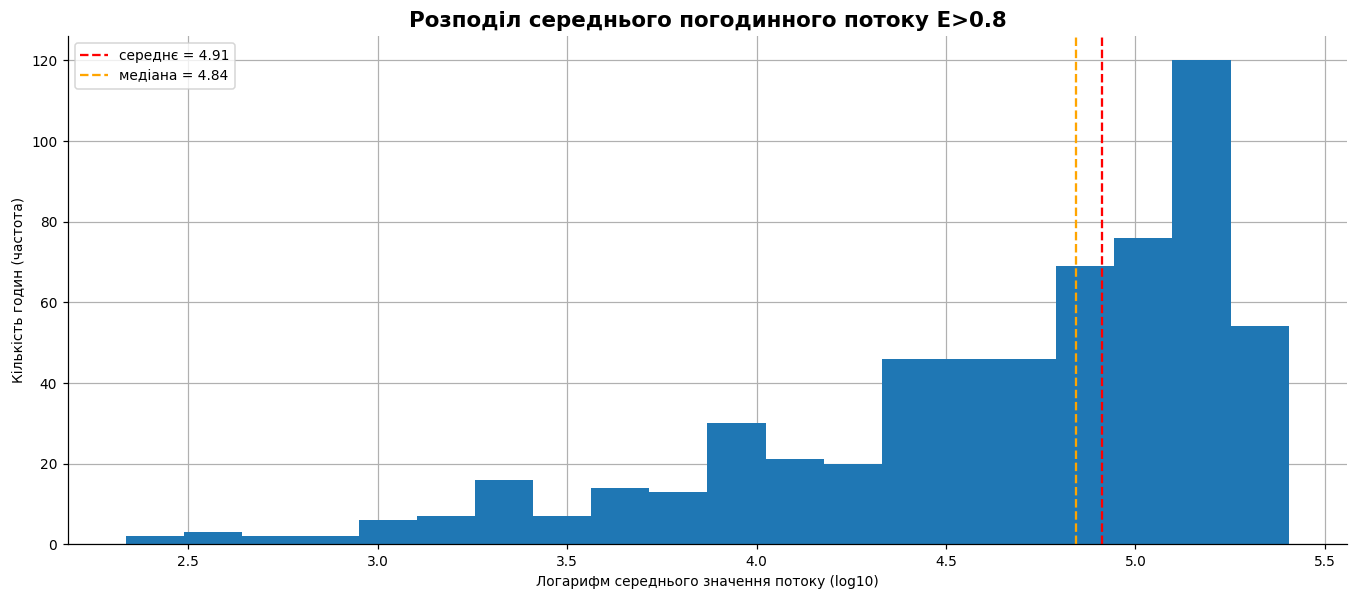

In [704]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.hist(np.log10(stream), bins=20)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('Логарифм середнього значення потоку (log10)')
ax.set_ylabel('Кількість годин (частота)')
ax.set_title('Розподіл середнього погодинного потоку E>0.8', fontsize=14, fontweight='bold')
ax.axvline(np.log10(mean), color='red', linestyle='--', label=f'середнє = {np.log10(mean):.2f}')
ax.axvline(np.log10(median), color='orange', linestyle='--', label=f'медіана = {np.log10(median):.2f}')

ax.legend()
plt.show()

**Висновок:** При обчисленнях середнього і медіани для стовпця E > 0.8, одержали такі значення: 81842.46818358586, 69712.5 
Ці два показники сильно відрізняються, оскільки, типовий потік насправді набагато вищий за медіанний рівень. Верхня гістограма показує, що найбільша кількість годин (120) припадає на діапазон $10^{5.1} - 10^{5.3}$. Подібні сплески тягнуть середнє арифметичне вгору, тоді як медіана є менш чутливою до цього.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

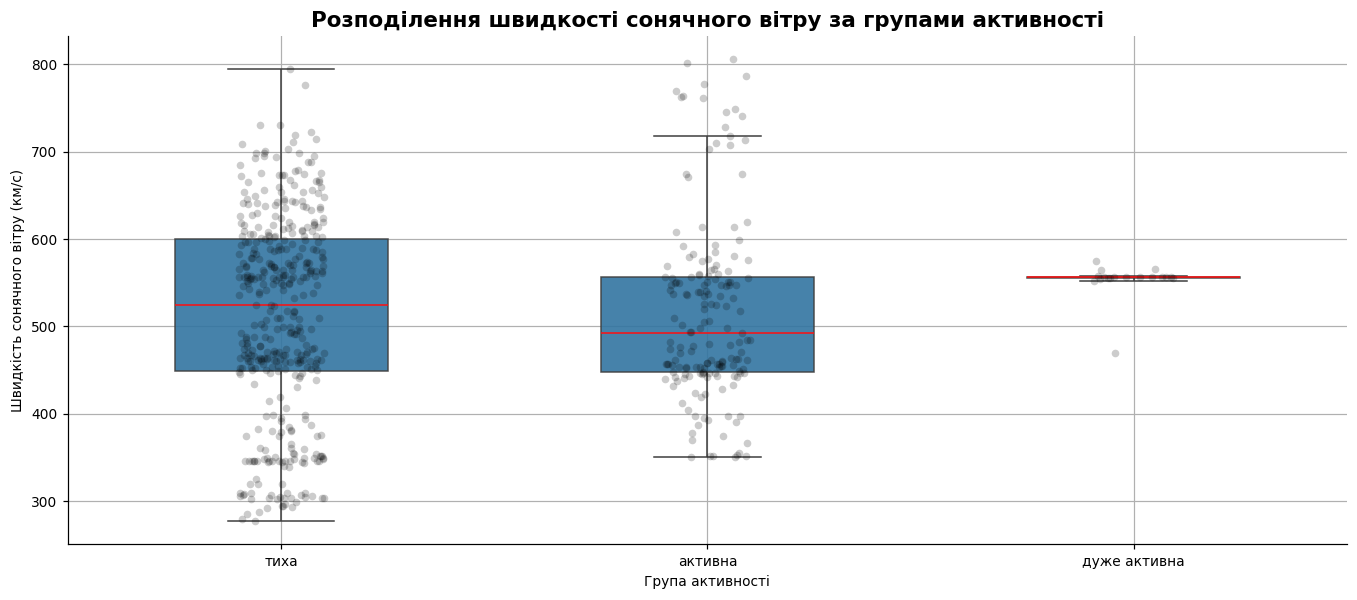

In [705]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(
    data=M, 
    x='група', 
    y='speed', 
    ax=ax,
    width=0.5,
    fliersize=0,                  
    boxprops=dict(alpha=0.9),     
    medianprops=dict(color="#FF0F0F") 
)

sns.stripplot(
    data=M, 
    x='група', 
    y='speed', 
    ax=ax,
    color='black',
    alpha=0.2,
    jitter=True
)

ax.set_xlabel('Група активності')
ax.set_ylabel('Швидкість сонячного вітру (км/с)')
ax.set_title('Розподілення швидкості сонячного вітру за групами активності',fontsize=14, fontweight='bold')
ax.grid(True)

plt.show()

**Висновок:** 

Тиха група - має рівномірно розподілену швидкість вітру (250 км/c - 800 км/с), різких зростань чи сповільнень немає.

Активна група - має численні різкі викиди понад 700 км/с. Медіана є нижчою ніж у "тихої" групи.

Дуже активна група - мало даних. Має майже постійну швидкість біля 560 км/с із поодиноким спадом. Медіана найбільша з-поміж усіх груп.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

In [706]:
correlation = M['e_grt_08_mean'].corr(M['p_grt_10_mean'])

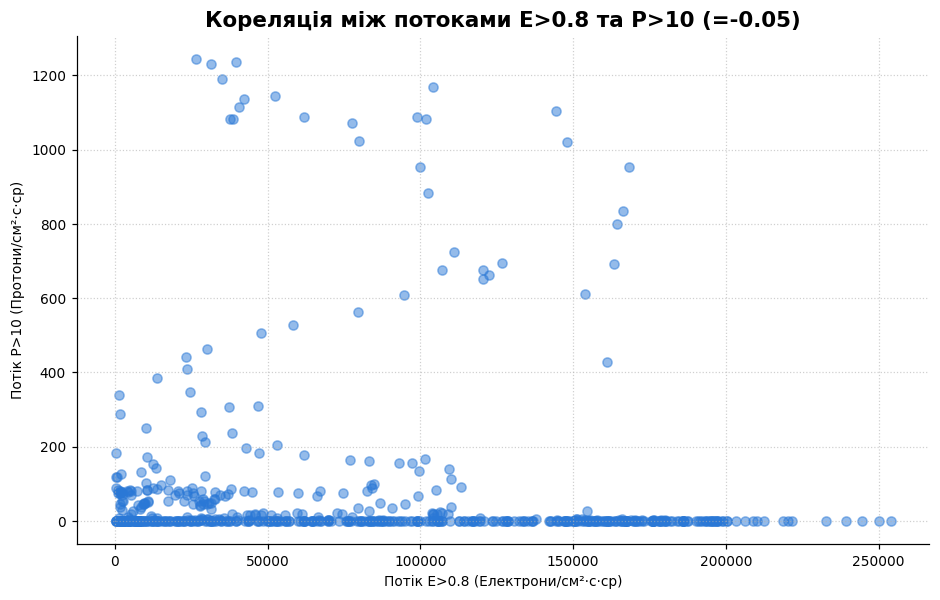

In [707]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(M['e_grt_08_mean'], M['p_grt_10_mean'], alpha=0.5, color='#2a78d6')
ax.set_xlabel('Потік E>0.8 (Електрони/см²·с·ср)')
ax.set_ylabel('Потік P>10 (Протони/см²·с·ср)')
ax.set_title(f'Кореляція між потоками E>0.8 та P>10 (={correlation:.2f})',fontsize=14, fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Висновок:** Одержаний коефіцієнт кореляції близький до 0, що говорить про відсутність зв'язку між двома потоками. Також, це можна побачити з графіку, оскільки, багато точок знаходяться на самій вісі Ох і деякі розкидані хаотично, не формуючи графік лінійної функції.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

In [708]:
group_counts = M['група'].value_counts()
total_hours = group_counts.sum()

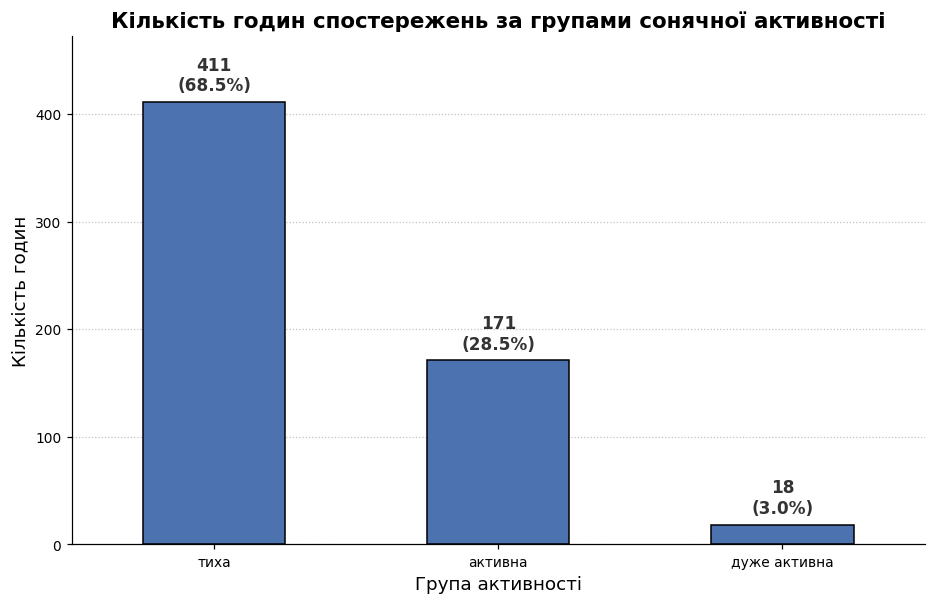

In [709]:
fig, ax = plt.subplots(figsize=(10, 6))

group_counts.plot(kind='bar', ax=ax, color='#4c72b0', edgecolor='black', alpha=1)

ax.set_title('Кількість годин спостережень за групами сонячної активності', fontsize=14, fontweight='bold')
ax.set_xlabel('Група активності', fontsize=12)
ax.set_ylabel('Кількість годин', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.8)
ax.set_axisbelow(True)

for p in ax.patches:
    count = int(p.get_height())                  
    percentage = (count / total_hours) * 100     
    
    label_text = f'{count}\n({percentage:.1f}%)'
    
    ax.annotate(label_text,
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom',                
                xytext=(0, 5),                           
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#333333')

plt.xticks(rotation=0)
ax.set_ylim(0, group_counts.max() * 1.15) 

plt.show()

**Висновок:** "Тиха група мала найбільше спостережень, відповідно, це вказує на те, що космічна погода була спокійною.
Група "дуже актина" має найменше спостережень.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

In [710]:
stream_p_10_max = M['p_grt_10_max']
stream_p_10_max = np.log10(stream_p_10_max)

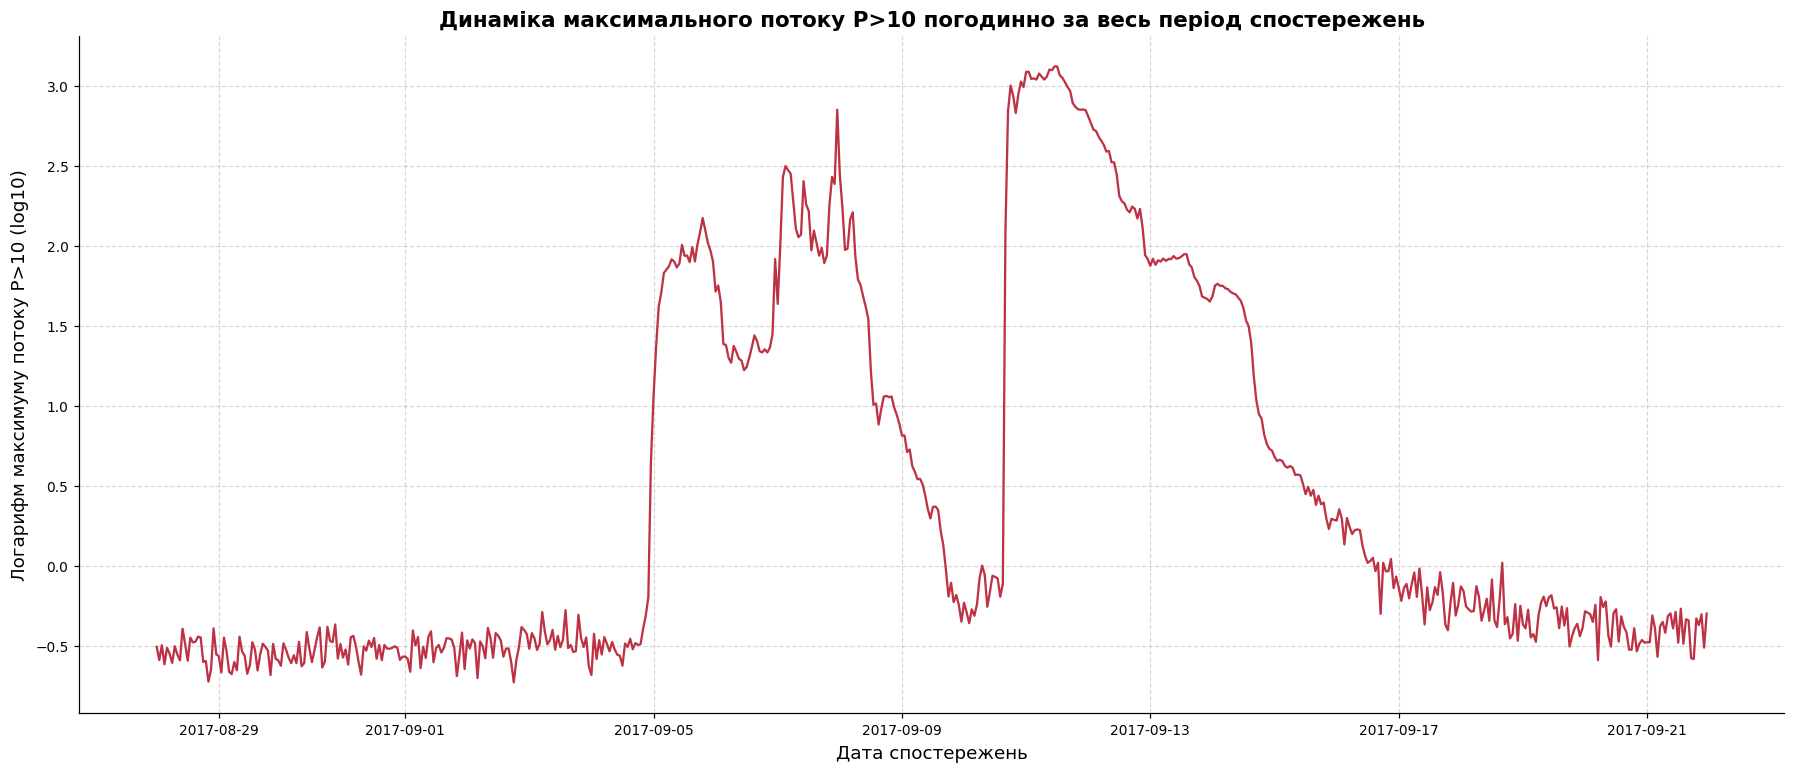

In [711]:
fig, ax = plt.subplots(figsize=(20, 8))

ax.set_title('Динаміка максимального потоку P>10 погодинно за весь період спостережень', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата спостережень', fontsize=12)
ax.set_ylabel('Логарифм максимуму потоку P>10 (log10)', fontsize=12)

ax.plot(M['ts'], stream_p_10_max, color='#bd3345')


ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

**Висновок:** 
Перший шторм тривав з 5 по 10 вересня, після чого стався другий, ще потужніший з 10 по 11 вересня і потім енергія плавно спала до 17 вересня. 

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

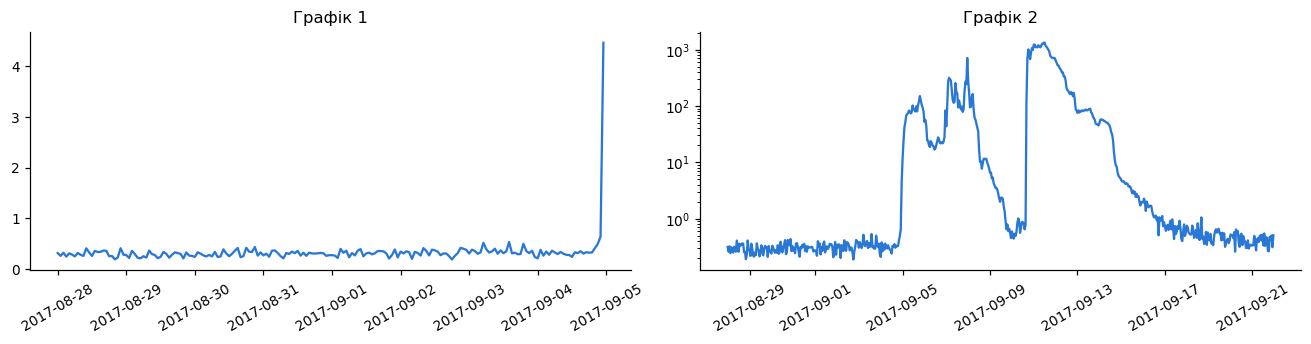

In [712]:
СТОВПЕЦЬ = 'p_grt_10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина подумає, що тільки з 4 по 5 вересня вибухнула буря, а до цього було дуже спокійно.
2. Висновок з другого графіка: Людина побачить що було 2 спалахи бурі і дрібні коливання у спокійніші дні.
3. Дві відмінності між ними: 
Перша - різний діапазон часу. Для першого графіка він обрізаний і показує тільки з 28 серпня по 5 вересня. У другому графіку з 28 серпня по 22 вересня
Друга - вісь Оy. На першому графіку лінійна шкала, на другому переведа в логарифмічну.

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

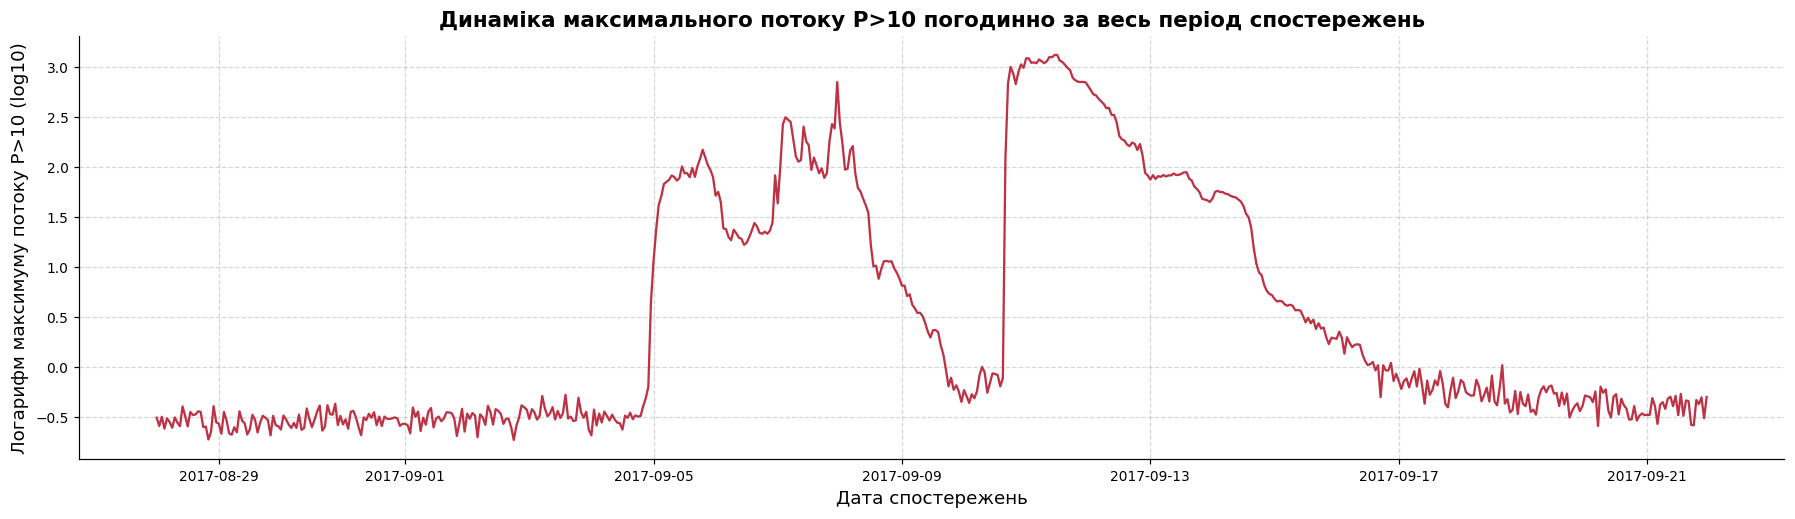

In [713]:
fig, ax = plt.subplots(figsize=(20, 5))

ax.set_title('Динаміка максимального потоку P>10 погодинно за весь період спостережень', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата спостережень', fontsize=12)
ax.set_ylabel('Логарифм максимуму потоку P>10 (log10)', fontsize=12)

ax.plot(M['ts'], stream_p_10_max, color='#bd3345')


ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

**Відповідь 6.2:** *По-перше, я взяла весь часовий діапазон, щоб для іншої людини було видно повну динаміку погоди. По-друге, я записи потоків перевела в логарифмічні значення, оскільки, є великий розкид до сотень тисяч. Такимч чином видно одночасно і дрібні коливання у тихі дні та великі стрибки під час штормів, і графік не виглядає як майже плочка лінія з різким зростанням.*

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Розподіл потоку E>0.8 сильно скошений: середнє на 17% вище за медіану (етап 5: графік 1).

**Спостереження 2:** Найпотужніший сплеск потоку P>10 стався 10–11 вересня 2017 року і
перевищив фоновий рівень приблизно у 7000 разів, тоді як решта періоду
(28.08–05.09) залишалась практично на нулі (етап 5: графік 5).

**Спостереження 3:** Незважаючи на те, що всі показники вимірювалися під час одних і тих самих подій, між потоком E>0.8 та P>10 немає лінійної кореляції (коефіцієнт -0.05). Їхні значення змінюються хаотично одне відносно одного (етап 5: графік 3).

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [714]:
stream = M['e_grt_08_mean']
median = stream.median()
print(f"Медіана: {median}")
print(f"Годин вище медіани за весь період: {(stream > median).sum()}")

Медіана: 69712.5
Годин вище медіани за весь період: 300


**Відповідь 7.2:** За весь період (600 годин) потік E>0.8 перевищував власну медіану 300 годин.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [715]:
ІНСТРУМЕНТИ_ШІ = 'Gemini, Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'ні',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = (
    "Який тип об'єднання таблиць краще обрати: inner чи outer. "
    "Розбирала логіку побудови графіків."
    "З'ясовувала, чим відрізняється графік, побудований за попередньо логарифмованими даними, від графіка з оригінальними значеннями."
    "Перевіряла згенеровані висновки за графіками."
    "Перефразовувала формулювання фінальних спостережень."
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [716]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Паничевська Ярина Ернестівна
інструменти:                                   Gemini, Claude
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        ні
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Який тип об'єднання таблиць краще обрати: inner чи outer. Розбирала логіку побудови графіків.З'ясовувала, чим відрізняється графік, побудований за попередньо логарифмованими даними, від графіка з оригінальними значеннями.Перевіряла згенеровані висновки за графіками.Пе

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [717]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [718]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
